<h1>Conjunto de datos sobre el rendimiento estudiantil y hábitos de estudio</h1>
<p>Conjunto de datos simulado que analiza cómo afectan los hábitos de estudio, el estilo de vida y la demografía</p>

<b>Utilizando la libreria Pytorch, reconstruir todos los modelos de los primeros cinco laboratorios, considerando objetos para manejo de datos (Dataset y Dataloader), objetos para optimizacion y costo, Objetos para guardar los pesos y otros que considere importantes, se debe considererar la generación de metricas.</b>

In [2]:
# Esta celda importa librerías para manejo de datos, álgebra y gráficos.
# Sirve para preparar el entorno antes del entrenamiento del modelo.
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo en uso: {device}')

Dispositivo en uso: cuda


In [3]:

dataset = r'E:\USFX\7mo Semestre\Inteligencia Artificial\Laboratorios\Laboratorio1\student_performance_dataset.csv'
print(f'Archivo a usar: {os.path.abspath(dataset)}')

Archivo a usar: E:\USFX\7mo Semestre\Inteligencia Artificial\Laboratorios\Laboratorio1\student_performance_dataset.csv


In [4]:
df = pd.read_csv(dataset, sep=',', header=None)

x = torch.tensor(df.iloc[:, 2].values, dtype=torch.float32).to(device)
y = torch.tensor(df.iloc[:, 10].values, dtype=torch.float32).to(device)

m = x.shape[0]
print(f'Número de muestras: {m}')
print(f'Tamaño de x: {x.shape}')
print(f'Tamaño de y: {y.shape}')

Número de muestras: 1000
Tamaño de x: torch.Size([1000])
Tamaño de y: torch.Size([1000])


In [5]:
print('Valores de X:')
print(x)

Valores de X:
tensor([4.0000, 6.3000, 4.9000, 2.6000, 2.2000, 4.2000, 1.5000, 6.2000, 5.3000,
        2.8000, 0.9000, 5.5000, 3.3000, 5.4000, 1.1000, 2.6000, 3.5000, 3.6000,
        2.8000, 4.4000, 1.9000, 3.3000, 3.7000, 4.3000, 4.6000, 1.8000, 1.2000,
        5.4000, 4.0000, 2.4000, 5.8000, 3.7000, 5.3000, 3.6000, 6.6000, 6.1000,
        3.1000, 5.0000, 4.5000, 5.6000, 2.1000, 4.5000, 5.1000, 0.9000, 1.7000,
        0.5000, 3.1000, 4.6000, 5.8000, 3.6000, 5.9000, 1.4000, 0.9000, 3.4000,
        4.1000, 3.5000, 0.5000, 3.4000, 1.5000, 4.5000, 4.0000, 2.1000, 2.7000,
        1.9000, 3.4000, 4.9000, 2.0000, 4.3000, 2.7000, 2.3000, 3.3000, 1.9000,
        2.7000, 1.7000, 6.4000, 3.6000, 2.5000, 3.8000, 3.3000, 3.2000, 4.4000,
        4.6000, 2.7000, 2.6000, 3.1000, 0.5000, 1.2000, 5.6000, 6.0000, 3.1000,
        4.4000, 4.0000, 8.1000, 5.2000, 3.3000, 2.1000, 1.1000, 3.8000, 2.4000,
        1.4000, 2.5000, 1.9000, 6.0000, 4.8000, 3.5000, 5.7000, 3.6000, 2.2000,
        5.8000, 4.3000, 1.

In [6]:
print('Valores de Y:')
print(y)

Valores de Y:
tensor([100.0000, 100.0000,  97.3000,  83.8000,  68.3000,  81.6000,  69.6000,
         88.0000,  84.4000,  74.3000,  68.9000,  76.7000,  82.6000,  93.3000,
         73.9000,  84.8000,  81.5000,  75.5000,  89.7000,  92.8000,  73.5000,
        100.0000,  73.4000,  71.2000,  97.2000,  76.0000,  78.7000,  97.4000,
         84.2000,  89.8000,  82.4000,  87.7000, 100.0000,  93.3000, 100.0000,
         92.9000,  83.2000,  81.1000,  89.5000,  91.6000,  75.3000,  79.0000,
        100.0000,  79.2000,  70.8000,  61.8000,  68.0000,  80.3000,  88.6000,
         69.4000, 100.0000,  81.8000,  72.6000,  85.3000,  99.8000,  84.3000,
         71.5000,  84.3000,  74.5000,  89.5000,  80.4000,  71.1000,  87.8000,
         73.0000,  80.8000,  97.4000,  67.8000,  79.2000,  73.5000,  85.1000,
         79.6000,  77.4000,  94.6000,  77.6000,  99.9000,  64.4000,  71.9000,
         79.3000,  74.9000,  87.4000,  97.6000,  74.5000,  64.1000,  90.0000,
         99.3000,  63.9000,  79.0000, 100.0000,  7

In [7]:
print(df)

       0       1    2      3    4            5    6    7    8     9      10 11
0       1    Male  4.0   98.0  6.5    Bachelors  Yes  Yes   No  76.9  100.0  A
1       2  Female  6.3  100.0  5.7  High School  Yes  Yes  Yes  75.5  100.0  A
2       3    Male  4.9   85.3  7.9    Bachelors  Yes   No  Yes  88.5   97.3  A
3       4    Male  2.6   77.5  8.0          NaN  Yes  Yes   No  85.1   83.8  B
4       5    Male  2.2   89.6  4.6    Bachelors  Yes   No  Yes  61.8   68.3  D
..    ...     ...  ...    ...  ...          ...  ...  ...  ...   ...    ... ..
995   996    Male  2.8   75.4  8.2      Masters  Yes  Yes   No  60.5   70.7  C
996   997    Male  6.7   88.4  7.1          NaN   No  Yes   No  82.2   99.5  A
997   998  Female  2.6   84.5  8.0  High School  Yes  Yes  Yes  65.2   79.2  C
998   999  Female  4.6   85.3  8.1  High School   No   No  Yes  52.2   82.2  B
999  1000    Male  3.9   77.4  6.1      Masters  Yes   No   No  45.4   70.4  C

[1000 rows x 12 columns]


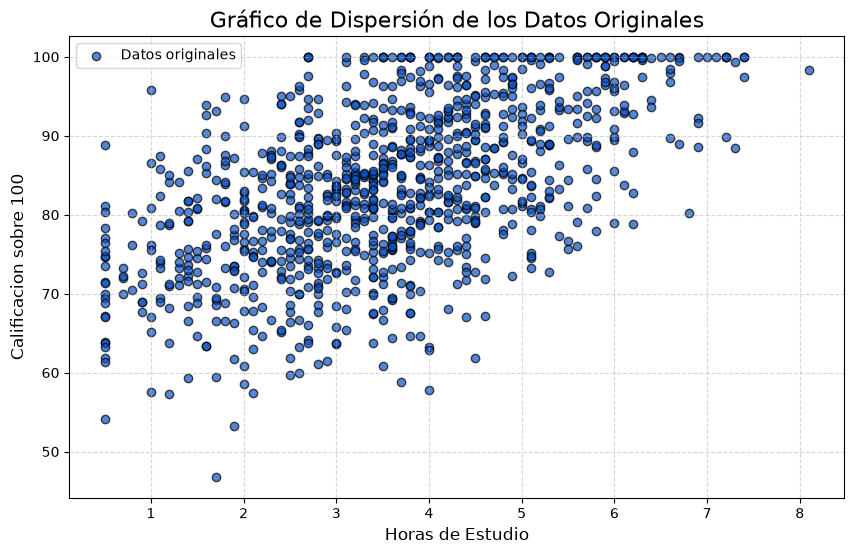

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(x.cpu().numpy(), y.cpu().numpy(), color="#0d53c4", alpha=0.7, edgecolors='k', label='Datos originales')
plt.title('Gráfico de Dispersión de los Datos Originales', fontsize=16)
plt.xlabel('Horas de Estudio', fontsize=12)
plt.ylabel('Calificacion sobre 100', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [9]:
n = x.shape[0]

b_min, b_max = 40, 80
w_min, w_max = -10, 10
paso = 0.03

# Todos los valores posibles de w, como un solo vector (no uno por uno)
w_vals = torch.arange(w_min, w_max + paso, paso, device=device)

# El umbral de cada muestra no cambia nunca, así que se calcula UNA sola vez, fuera de todo bucle
umbral = 0.05 * torch.abs(y)   # forma: (n,)

mejor_acum = -1
mejor_b = 0
mejor_w = 0
total_combinaciones = 0

b = b_min
while b <= b_max:
    # En vez de recorrer w y las n muestras una por una, se comparan TODAS a la vez:
    # y_pred tendrá forma (num_w, n) -> una fila por cada valor de w, con las n predicciones
    y_pred = b + w_vals.view(-1, 1) * x.view(1, -1)
    error = torch.abs(y.view(1, -1) - y_pred)

    # aciertos: cuántas muestras cumplieron el umbral, para cada w (todo de una vez)
    aciertos_por_w = (error < umbral.view(1, -1)).sum(dim=1)

    # de todos los w probados con este b, cuál dio más aciertos
    mejor_w_idx = torch.argmax(aciertos_por_w)
    acum = aciertos_por_w[mejor_w_idx].item()

    if acum > mejor_acum:
        mejor_acum = acum
        mejor_b = b
        mejor_w = w_vals[mejor_w_idx].item()

    total_combinaciones += len(w_vals)
    b = b + paso

print("--- Búsqueda completada ---")
print(f"Combinaciones evaluadas: {total_combinaciones}")
print(f"Mejor b: {mejor_b:.4f}, Mejor w: {mejor_w:.4f}, Aciertos: {mejor_acum}")

--- Búsqueda completada ---
Combinaciones evaluadas: 891112
Mejor b: 65.1400, Mejor w: 5.1500, Aciertos: 401


x = 1.00 horas -> y predicho = 70.29
x = 2.50 horas -> y predicho = 78.01
x = 3.00 horas -> y predicho = 80.59
x = 4.20 horas -> y predicho = 86.77
x = 5.00 horas -> y predicho = 90.89
x = 5.50 horas -> y predicho = 93.46
x = 6.00 horas -> y predicho = 96.04
x = 6.80 horas -> y predicho = 100.00
x = 7.20 horas -> y predicho = 100.00
x = 8.00 horas -> y predicho = 100.00
la presicion del modelo es: 0.4010 


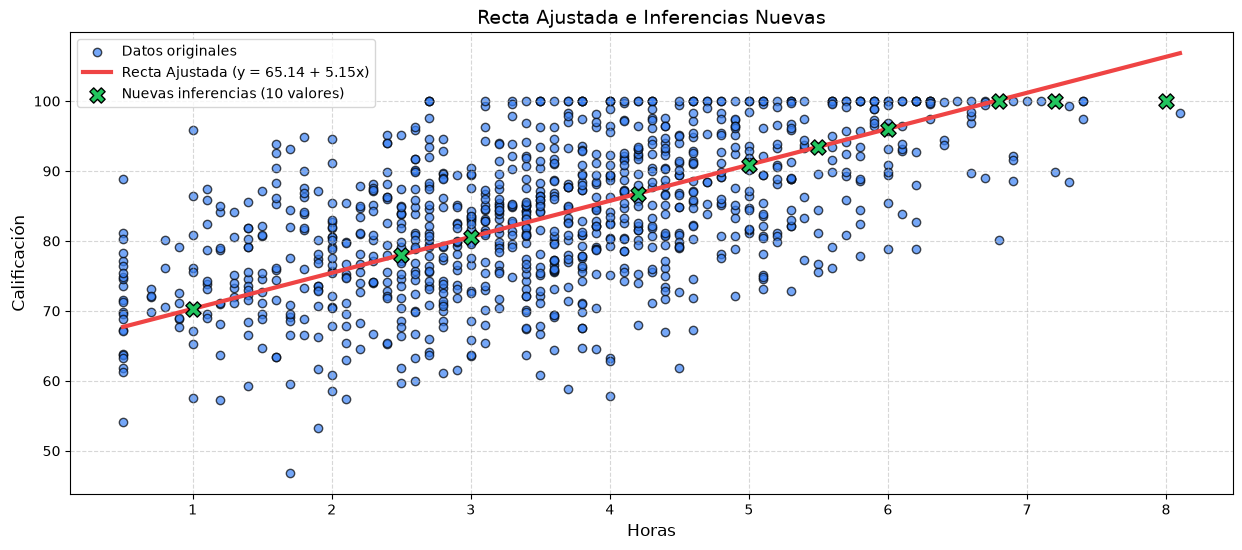

In [11]:
x_nuevos = torch.tensor([1.0, 2.5, 3.0, 4.2, 5.0, 5.5, 6.0, 6.8, 7.2, 8.0], dtype=torch.float32).to(device)
y_inferido = mejor_b + mejor_w * x_nuevos
y_inferido = torch.clamp(y_inferido, max=100.0)

for i in range(10):
    print(f"x = {x_nuevos[i].item():.2f} horas -> y predicho = {y_inferido[i].item():.2f}")
    
print(f'la presicion del modelo es: {mejor_acum / n:.4f} ')

# Gráfico final con la recta ajustada + las nuevas inferencias
plt.figure(figsize=(15, 6))
plt.scatter(x.cpu().numpy(), y.cpu().numpy(), color='#3b82f6', alpha=0.7, edgecolors='k', label='Datos originales')

x_recta = torch.linspace(x.min(), x.max(), 100).to(device)
y_recta = mejor_b + mejor_w * x_recta
plt.plot(x_recta.cpu().numpy(), y_recta.cpu().numpy(), color='#ef4444', linewidth=3,
         label=f'Recta Ajustada (y = {mejor_b:.2f} + {mejor_w:.2f}x)')

plt.scatter(x_nuevos.cpu().numpy(), y_inferido.cpu().numpy(), color='#22c55e', marker='X', s=120,
            edgecolors='k', label='Nuevas inferencias (10 valores)', zorder=5)

plt.title('Recta Ajustada e Inferencias Nuevas', fontsize=14)
plt.xlabel('Horas', fontsize=12)
plt.ylabel('Calificación', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()